# States II: density of states (energy resolved)
The density of states counts eigenstates per unit energy,
$$ \rho(E) = \sum_n \delta(E-\epsilon_n) = -\frac{1}{\pi}\,\mathrm{Im}\,\mathrm{Tr}\,G(E),\qquad G(E) = \big[(E+i\delta)\mathbb{1} - H\big]^{-1} $$
It answers "how many states are there near energy $E$", independent of momentum. We compute it two ways: exact diagonalization over a k-mesh (good for small unit cells), and the kernel polynomial method (KPM), a stochastic, matrix-free trace estimator that scales to very large sparse systems.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

### DOS of honeycomb vs. kagome, from the bands of the previous notebook

In [2]:
energies = np.linspace(-4.,4.,300)

g_honey = geometry.honeycomb_lattice()
h_honey = g_honey.get_hamiltonian()
(e_honey,d_honey) = h_honey.get_dos(energies=energies,nk=60)

g_kagome = geometry.kagome_lattice()
h_kagome = g_kagome.get_hamiltonian()
(e_kagome,d_kagome) = h_kagome.get_dos(energies=energies,nk=60)

The honeycomb DOS vanishes linearly at $E=0$ (Dirac point), while the kagome DOS has a sharp peak where the flat band sits.

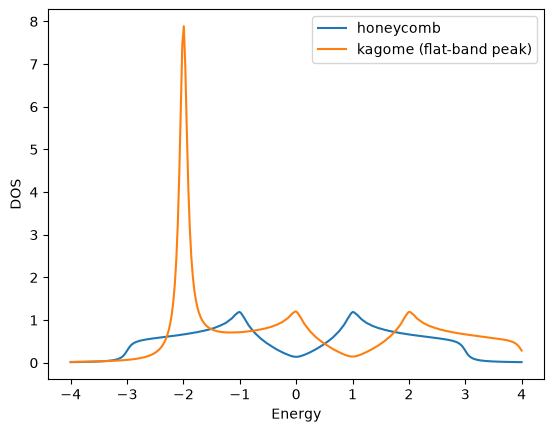

In [3]:
plt.plot(e_honey,d_honey,label="honeycomb")
plt.plot(e_kagome,d_kagome,label="kagome (flat-band peak)")
plt.xlabel("Energy") ; plt.ylabel("DOS")
plt.legend()
plt.show()

### DOS of a large disordered chain with the KPM
KPM never builds $G(E)$ explicitly: it expands the trace in Chebyshev polynomials of $H$ using only sparse matrix-vector products, so it scales to thousands of sites where exact diagonalization would not.

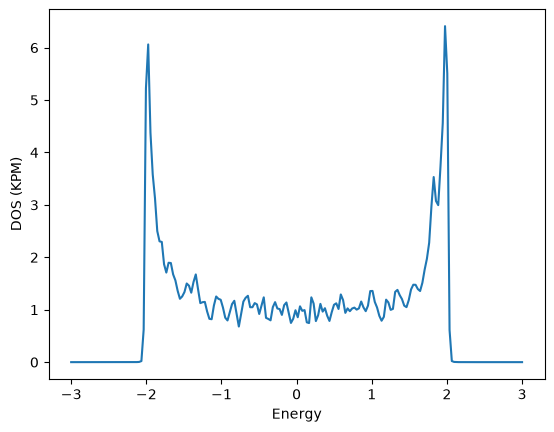

In [4]:
g = geometry.chain()
g = g.get_supercell(600) # large 1D supercell
g.dimensionality = 0     # treat as a finite (open) chain
h = g.get_hamiltonian(is_sparse=True, has_spin=False)

(xk,yk) = h.get_dos(mode="KPM",
                     energies=np.linspace(-3.,3.,200),
                     delta=1e-2,
                     ntries=5)

plt.plot(xk,yk)
plt.xlabel("Energy") ; plt.ylabel("DOS (KPM)")
plt.show()